# SigFlow-Sim v2 — Configurable Depth and Training Visualization

Enhancements:

- Adjustable signature depth from a single configuration cell
- Real-time progress bar using tqdm
- Live loss tracking
- Final training curve visualization
- Clean output summary after training


In [208]:
# Install once if needed
!pip install numpy pandas torch matplotlib iisignature nflows yfinance tqdm scikit-learn

## Configuration — Change Model Parameters Here

In [209]:
# =========================
# GLOBAL CONFIGURATION
# =========================

WINDOW = 20
DEPTH = 7
USE_LOGSIG = True

EPOCHS = 667
BATCH_SIZE = 128
LEARNING_RATE = 5e-5

TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN"]

# -------------------------
# FORECAST SETTINGS
# -------------------------

HORIZON = 10       
N_PATHS = 50        

# TOGGLE (NOW HERE AS REQUESTED)
MODE = "rolling"    # "rolling" or "one_shot"

In [210]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm

import iisignature

from sklearn.metrics.pairwise import rbf_kernel

from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform

## Load Market Data

In [211]:
import yfinance as yf
import numpy as np
import torch

all_returns = []

for ticker in TICKERS:

    data = yf.download(ticker, period="10y", interval="1d")

    prices = data["Close"]
    log_returns = np.log(prices / prices.shift(1)).dropna()

    # stabilise distribution (important for flows)
    log_returns = (log_returns - log_returns.rolling(50).mean()) / log_returns.rolling(50).std()
    log_returns = log_returns.dropna()

    all_returns.append(log_returns.values)

returns_array = np.concatenate(all_returns)

print("Total samples:", len(returns_array))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Total samples: 9860


## Signature / Log-Signature Computation

In [212]:
def compute_signature(window, prep):

    t = np.linspace(0, 1, len(window))
    path = np.column_stack([t, window])

    if USE_LOGSIG:
        return iisignature.logsig(path, prep)
    else:
        return iisignature.sig(path, prep)


prep = iisignature.prepare(2, DEPTH)

signatures = []
targets = []

STRIDE = 1  # NEW (more samples)

for i in range(WINDOW, len(returns_array) - 1, STRIDE):

    window = returns_array[i - WINDOW:i]

    signatures.append(compute_signature(window, prep))
    targets.append(returns_array[i])

X = torch.tensor(np.array(signatures), dtype=torch.float32)
Y = torch.tensor(np.array(targets), dtype=torch.float32).reshape(-1, 1)

print("X shape:", X.shape)

X shape: torch.Size([9839, 41])


## Build Neural Spline Flow

In [213]:
def build_flow(context_dim):

    transforms = []

    for _ in range(4):

        transforms.append(
            MaskedAffineAutoregressiveTransform(
                features=1,
                hidden_features=64,
                context_features=context_dim
            )
        )

    transform = CompositeTransform(transforms)

    base_dist = StandardNormal(shape=[1])

    return Flow(transform, base_dist)


flow = build_flow(X.shape[1])

optimizer = optim.Adam(flow.parameters(), lr=LEARNING_RATE)

In [214]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm

import iisignature

from sklearn.metrics.pairwise import rbf_kernel

from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform

## Wasserstein Loss

In [215]:
def fast_wasserstein(real, fake, k=8):

    q = torch.linspace(0, 1, k, device=real.device)

    real_q = torch.quantile(real.squeeze(), q)
    fake_q = torch.quantile(fake.squeeze(), q)

    return torch.mean(torch.abs(real_q - fake_q))

## Custom Loss

In [216]:
def custom_loss(flow, x_context, y_real, step=0, total_steps=1):

    log_prob = flow.log_prob(y_real, context=x_context)
    loss_mle = -log_prob.mean()

    # cheaper sampling (no gradient needed)
    with torch.no_grad():
        y_fake = flow.sample(len(y_real), context=x_context)

    loss_wass = fast_wasserstein(y_real, y_fake)

    alpha = WASS_START + (WASS_END - WASS_START) * (step / total_steps)

    return loss_mle + alpha * loss_wass

## Testing Block

Validates:

    data integrity

    numerical stability

    model forward pass

    sampling correctness

In [217]:
print("\nRUNNING TEST SUITE\n")

# Force safety check for accidental 3D tensors
if Y.ndim == 3 and Y.shape[-1] == 1:
    Y = Y.squeeze(-1)

assert X.ndim == 2, f"X is {X.shape}, expected 2D"
assert Y.ndim == 2, f"Y is {Y.shape}, expected 2D [N,1]"
assert X.shape[0] == Y.shape[0], "X and Y size mismatch"

assert torch.isfinite(X).all()
assert torch.isfinite(Y).all()

batch_x = X[:16].float().view(-1, X.shape[1])
batch_y = Y[:16].float().view(-1, 1)

loss = custom_loss(flow, batch_x, batch_y)
assert torch.isfinite(loss)

context = X[:1].float()
samples = flow.sample(10, context=context)

# enforce consistent shape
samples = samples.view(-1, 1)

assert samples.shape == (10, 1), f"Bad shape: {samples.shape}"

print("All tests passed")


RUNNING TEST SUITE

All tests passed


## Training with Progress Tracking

In [218]:
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

X = X.float().to(device)
Y = Y.float().to(device)
flow = flow.to(device)

# OPTIONAL speed boost
# flow = torch.compile(flow)

dataset = TensorDataset(X, Y)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

loss_history = []
global_step = 0
total_steps = EPOCHS * len(loader)

for epoch in range(EPOCHS):

    epoch_loss = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch_x, batch_y in pbar:

        optimizer.zero_grad()

        loss = custom_loss(flow, batch_x, batch_y, global_step, total_steps)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        global_step += 1

        pbar.set_postfix(loss=loss.item())

    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.5f}")

Epoch 1/667:   0%|          | 0/77 [00:00<?, ?it/s]/home/michael_cachy/FlowSigRL/SigFlowRL/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/667: 100%|██████████| 77/77 [00:01<00:00, 42.82it/s, loss=1.64]


Epoch 1 | Loss: 176.37437


Epoch 2/667: 100%|██████████| 77/77 [00:01<00:00, 46.91it/s, loss=1.64]


Epoch 2 | Loss: 116.82501


Epoch 3/667: 100%|██████████| 77/77 [00:01<00:00, 47.53it/s, loss=1.36]


...

Epoch 665 | Loss: 104.53607


Epoch 666/667: 100%|██████████| 77/77 [00:01<00:00, 45.53it/s, loss=1.36]


Epoch 666 | Loss: 104.42035


Epoch 667/667: 100%|██████████| 77/77 [00:01<00:00, 46.51it/s, loss=1.32]

Epoch 667 | Loss: 104.45857


## Training Curve Visualization

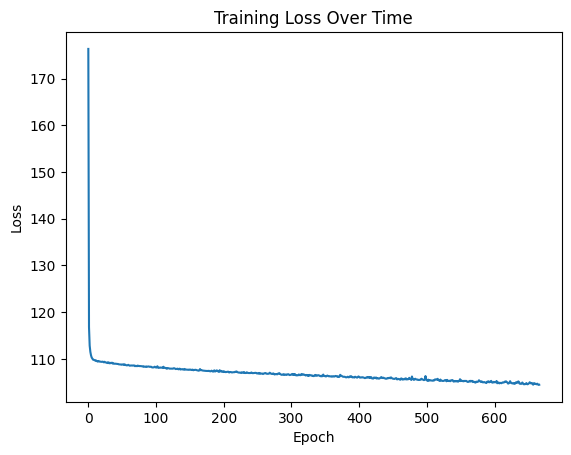

In [219]:
plt.figure()
plt.plot(loss_history)
plt.title("Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Monte Carlo Evaluation
Evaluates model by:

    sampling multiple predictions

    comparing distribution to actual outcome

    visualising uncertainty

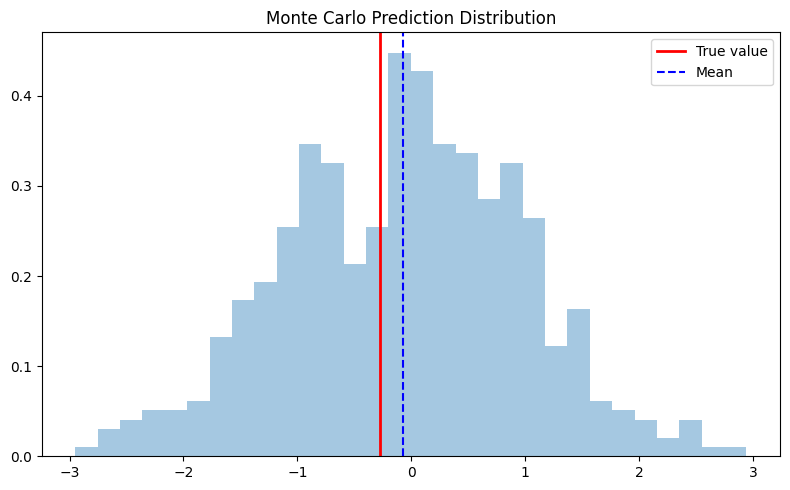


MONTE CARLO EVALUATION
Real value: -0.2763823866844177
Mean: -0.06949285
Std: 1.0329581


In [220]:

def monte_carlo_evaluation(flow, context, real_value, n_samples=500):

    import matplotlib.pyplot as plt
    import numpy as np

    # -------------------------
    # Fix context shape
    # -------------------------
    if context.ndim == 1:
        context = context.unsqueeze(0)

    context = context.float()

    # -------------------------
    # Sample
    # -------------------------
    samples = flow.sample(n_samples, context=context)
    samples = samples.view(-1).detach().cpu().numpy()

    real_value = real_value.view(-1).item()

    mean = samples.mean()
    std = samples.std()

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(8, 5))

    plt.hist(samples, bins=30, density=True, alpha=0.4)
    plt.axvline(real_value, color='red', linewidth=2, label="True value")
    plt.axvline(mean, color='blue', linestyle='--', label="Mean")

    plt.title("Monte Carlo Prediction Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Print stats
    # -------------------------
    print("\nMONTE CARLO EVALUATION")
    print("Real value:", real_value)
    print("Mean:", mean)
    print("Std:", std)

    return samples


# -------------------------
# CALL IT HERE (THIS IS THE KEY FIX)
# -------------------------

test_idx = -1

context = X[test_idx].float()
real = Y[test_idx]

samples = monte_carlo_evaluation(flow, context, real, n_samples=500)

## Posterior Predictive Output

Prediction mean: -0.04918583983579447
Prediction std: 0.9879704636790355


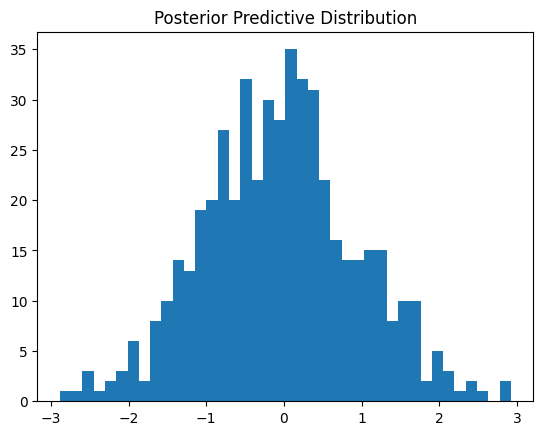

In [221]:
def posterior_predictive(flow, context, n_samples=500):

    samples = []

    for _ in range(n_samples):

        s = flow.sample(1, context=context.unsqueeze(0))

        samples.append(s.item())

    samples = np.array(samples)

    mean = np.mean(samples)
    std = np.std(samples)

    return samples, mean, std

latest_context = X[-1]

samples, mean, std = posterior_predictive(flow, latest_context)

print("Prediction mean:", mean)
print("Prediction std:", std)

plt.figure()
plt.hist(samples, bins=40)
plt.title("Posterior Predictive Distribution")
plt.show()

## Path Generation

In [222]:
import numpy as np
import torch

def generate_paths(flow, context, horizon=HORIZON, n_paths=N_PATHS, mode=MODE):

    paths = []

    for _ in range(n_paths):

        current = context.clone()
        path = []

        for t in range(horizon):

            sample = flow.sample(1, context=current.unsqueeze(0))
            r = sample.item()

            path.append(r)

            if mode == "rolling":
                current = torch.roll(current, shifts=-1)
                current[-1] = r

        paths.append(path)

    return np.array(paths)

## Price Conversion

In [223]:
def returns_to_price(start_price, returns):

    prices = [float(start_price)]

    for r in np.asarray(returns).flatten():

        prices.append(prices[-1] * np.exp(float(r)))

    return np.array(prices, dtype=np.float32)

## Outlier Function

In [224]:
import numpy as np

def detect_outliers(data):

    data = np.array(data)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (data < lower) | (data > upper)

    outliers = data[mask]

    return mask, outliers, lower, upper

## Visualisation System

In [225]:
import matplotlib.pyplot as plt
import numpy as np

def forecast_visual(flow, X, returns_array, idx=-200):

    context = X[idx]

    # -------------------------
    # SAFE ACTUAL PATH
    # -------------------------
    actual_returns = returns_array[idx : idx + HORIZON]
    actual_returns = np.array(actual_returns).flatten()

    # -------------------------
    # MODEL PATHS (RETURN SPACE)
    # -------------------------
    paths = generate_paths(flow, context)

    all_series = []

    plt.figure(figsize=(10,6))

    for p in paths:
        p = np.array(p).flatten()
        all_series.extend(p)
        plt.plot(p, alpha=0.15, color="blue")

    # mean path
    mean_path = np.mean(paths, axis=0)
    mean_path = np.array(mean_path).flatten()

    all_series.extend(mean_path)
    plt.plot(mean_path, color="blue", linewidth=2, label="Mean prediction")

    # actual
    all_series.extend(actual_returns)
    plt.plot(actual_returns, color="red", linewidth=2, label="Actual")

    # -------------------------
    # ZERO LINE
    # -------------------------
    plt.axhline(0, color="black", linewidth=1)

    # -------------------------
    # SYMMETRIC AXIS (FIXED NEGATIVE SUPPORT)
    # -------------------------
    all_series = np.array(all_series, dtype=np.float32)

    abs_max = np.max(np.abs(all_series))

    padding = 1.1

    plt.ylim(-abs_max * padding, abs_max * padding)

    # -------------------------
    # STATS OUTPUT
    # -------------------------
    print("\n📊 MODEL SUMMARY")
    print("Total points:", len(all_series))
    print("Mean prediction:", np.mean(mean_path))
    print("Volatility:", np.std(all_series))
    print("Max magnitude:", abs_max)

    # -------------------------
    # FINAL PLOT
    # -------------------------
    plt.title(f"Return Forecast | Horizon={HORIZON} | Mode={MODE}")
    plt.legend()
    plt.show()

## Run it


📊 MODEL SUMMARY
Total points: 520
Mean prediction: -0.36573718588706106
Volatility: 3.7752576
Max magnitude: 75.48194


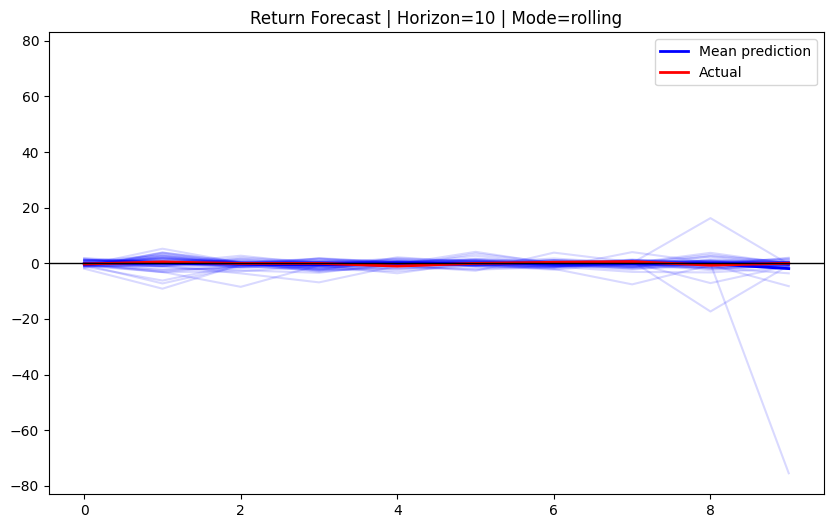

In [226]:
prices_series = np.exp(np.cumsum(returns_array))

forecast_visual(flow, X, returns_array, idx=-200)